In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

In [7]:
DATA_PATH = "MetroPT3.csv"
CHUNK_SIZE = 50000
TIMESTEPS = 10
BATCH_SIZE = 8

scaler = MinMaxScaler()

# الأعمدة (15 feature)
feature_columns = [
    "TP2", "TP3", "H1", "DV_pressure", "Reservoirs",
    "Oil_temperature", "Motor_current", "COMP",
    "DV_eletric", "Towers", "MPG", "LPS",
    "Pressure_switch", "Oil_level", "Caudal_impulses"
]

In [8]:
def create_sequences(data, seq_len):
    xs = []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
    return np.array(xs)


In [9]:
input_dim = len(feature_columns)

inputs = Input(shape=(TIMESTEPS, input_dim))
encoded = LSTM(32, activation='relu')(inputs)
decoded = RepeatVector(TIMESTEPS)(encoded)
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(input_dim))(decoded)

model = Model(inputs, decoded)
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 15)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 15)         │           495 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,959 (58.43 KB)

 Trainable params: 14,959 (58.43 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("\n🚀 Training using chunks...")

for i, chunk in enumerate(pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE)):

    # حذف index العمود
    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)

    # timestamp
    chunk["timestamp"] = pd.to_datetime(chunk["timestamp"])
    chunk = chunk.sort_values("timestamp")

    # اختيار الأعمدة
    chunk = chunk[["timestamp"] + feature_columns]

    # حذف timestamp
    chunk = chunk.drop(columns=["timestamp"])

    # تحويل float
    X_chunk = chunk.values.astype(np.float32)

    # fit scaler أول مرة فقط
    if i == 0:
        scaler.fit(X_chunk)

    X_scaled = scaler.transform(X_chunk)

    # sequences
    X_seq = create_sequences(X_scaled, TIMESTEPS)

    if len(X_seq) == 0:
        continue

    # training
    model.fit(
        X_seq, X_seq,
        epochs=1,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    print(f"✅ Chunk {i+1} trained: {len(X_seq)} sequences")

print("\n🎯 Training completed!")



🚀 Training using chunks...
✅ Chunk 1 trained: 49990 sequences
✅ Chunk 2 trained: 49990 sequences
✅ Chunk 3 trained: 49990 sequences
✅ Chunk 4 trained: 49990 sequences
✅ Chunk 5 trained: 49990 sequences
✅ Chunk 6 trained: 49990 sequences
✅ Chunk 7 trained: 49990 sequences
✅ Chunk 8 trained: 49990 sequences
✅ Chunk 9 trained: 49990 sequences
✅ Chunk 10 trained: 49990 sequences
✅ Chunk 11 trained: 49990 sequences
✅ Chunk 12 trained: 49990 sequences
✅ Chunk 13 trained: 49990 sequences
✅ Chunk 14 trained: 49990 sequences
✅ Chunk 15 trained: 49990 sequences
✅ Chunk 16 trained: 49990 sequences
✅ Chunk 17 trained: 49990 sequences
✅ Chunk 18 trained: 49990 sequences
✅ Chunk 19 trained: 49990 sequences
✅ Chunk 20 trained: 49990 sequences
✅ Chunk 21 trained: 49990 sequences
✅ Chunk 22 trained: 49990 sequences
✅ Chunk 23 trained: 49990 sequences
✅ Chunk 24 trained: 49990 sequences
✅ Chunk 25 trained: 49990 sequences
✅ Chunk 26 trained: 49990 sequences
✅ Chunk 27 trained: 49990 sequences
✅ Chunk 2

In [11]:
print("\n📊 Evaluating...")

all_errors = []

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):

    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)

    chunk["timestamp"] = pd.to_datetime(chunk["timestamp"])
    chunk = chunk.sort_values("timestamp")

    chunk = chunk[["timestamp"] + feature_columns]
    chunk = chunk.drop(columns=["timestamp"])

    X_chunk = chunk.values.astype(np.float32)
    X_scaled = scaler.transform(X_chunk)

    X_seq = create_sequences(X_scaled, TIMESTEPS)

    if len(X_seq) == 0:
        continue

    X_pred = model.predict(X_seq, verbose=0)

    mse = np.mean(np.power(X_seq - X_pred, 2), axis=(1,2))
    all_errors.extend(mse)

all_errors = np.array(all_errors)



📊 Evaluating...


In [28]:
# THRESHOLD
# =========================================================

threshold = np.percentile(all_errors, 98)

y_pred = (all_errors > threshold).astype(int)

# pseudo labels (approximation)
mean = np.mean(all_errors)
std = np.std(all_errors)

y_true = (all_errors > mean + 3*std)

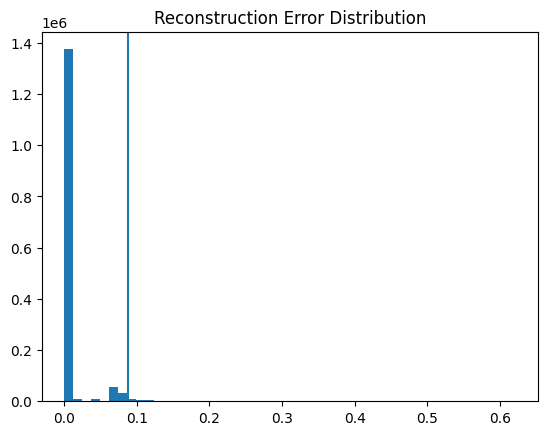


📊 RESULTS METROPT3
Precision: 0.8347325818644011
Recall   : 1.0
F1-score : 0.9099228848011959


In [29]:
import matplotlib.pyplot as plt

plt.hist(all_errors, bins=50)
plt.axvline(threshold)
plt.title("Reconstruction Error Distribution")
plt.show()
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)

print("\n📊 RESULTS METROPT3")
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)